# Variables del módulo de criticidad

Este notebook consolida el **análisis de `tesis2`** y la literatura sobre clasificación de criticidad / incertidumbre, y define el **contrato de variables** correcto para:

1. **Corpus gold** (`play` / `pausa` / `stop`)
2. **EarlyGate** (gate temprano sobre texto)
3. **Baseline ML** (TF-IDF, sin LLM)
4. **Sentinel** (riesgo sobre blueprint — capa distinta)

**Relacionado:** `semana6_entrega_criticidad_ab.ipynb` (entrega sprint sem. 6), `eval_early_gate_vs_gold.ipynb` (eval con API), `scripts/run_week6_experiments.py` (A/B + artefactos week6), `scripts/run_week5_experiments.py` (baseline repo padre).

**Cwd:** ejecutar desde `tesis2` o `tesis2/notebooks` (debe encontrarse `agentes/core/early_gate.py`).

## 1. Tres capas de "criticidad" (no mezclar namespaces)

| Capa | Dónde | Variable objetivo | Entrada principal |
|------|-------|-------------------|-------------------|
| **Política operativa** | Corpus + EarlyGate | `gold_mode`: `play` \| `pausa` \| `stop` | `requirement` (texto) |
| **Baseline ML** | `run_week5_experiments.py` / `run_week6_experiments.py` | Misma etiqueta `gold_mode` | Solo `requirement` → TF-IDF |
| **Riesgo técnico** | Arquitecto + Sentinel | `criticality` LOW/MEDIUM/HIGH + `RiskScore` | Blueprint TOON, no texto crudo |

El módulo de criticidad de la tesis (corpus + gate + eval) trabaja con la **primera fila**. Sentinel es complementario y **posterior** al blueprint.

In [1]:
%matplotlib inline

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="notebook")


def find_tesis2_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "agentes" / "core" / "early_gate.py").is_file():
            return p
    raise FileNotFoundError(
        "No se encontró tesis2: cwd debe ser `tesis2` o un subdirectorio."
    )


TESIS2_ROOT = find_tesis2_root()
AGENTES_DIR = TESIS2_ROOT / "agentes"
CORPUS = TESIS2_ROOT / "data" / "criticidad_cases" / "casos_gold_criticidad_v2.jsonl"
LABELS = ["play", "pausa", "stop"]

sys.path.insert(0, str(AGENTES_DIR))
from core.early_gate import (
    EarlyGate,
    PAUSE_PATTERNS,
    PLAY_PATTERNS,
    STOP_PATTERNS,
)

print("TESIS2_ROOT =", TESIS2_ROOT)
print("Corpus:", CORPUS, "→", CORPUS.is_file())

TESIS2_ROOT = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2
Corpus: /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/data/criticidad_cases/casos_gold_criticidad_v2.jsonl → True


## 2. Contrato de variables (corpus gold)

Fuente: `src/criticidad_case_types.py`, `PROTOCOLO_ETIQUETADO.md`.

### Obligatorias (consumo del módulo)

| Variable | Tipo | Rol |
|----------|------|-----|
| `id` | string | Identificador `CRT-{PLAY\|PAUSE\|STOP}-NNN` |
| `gold_mode` | enum | **Etiqueta** de referencia |
| `requirement` | string | **Única feature de entrada** para clasificadores de texto |

### Metadatos (evaluación / diseño, no como features directas)

| Variable | Uso correcto |
|----------|--------------|
| `template_index` | **Grupo** en `GroupKFold` (evita fuga por plantilla) |
| `difficulty_hint` | Estratificación / análisis, no sustituye `gold_mode` |
| `schema_version`, `literature_axis` | Trazabilidad del corpus |
| `rationale_gold` | Documentación humana; **no** entrenar sin control de leakage |
| `tags` | Contienen la clase (`play` en tags) → **riesgo de leakage** |

### Prohibidas como features de clasificación

- Prefijo de `id` (`CRT-PLAY-…`)
- `tags`, `rationale_gold`

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


df = load_jsonl(CORPUS)
print(f"Filas: {len(df)}")
display(df["gold_mode"].value_counts().sort_index())
display(df.head(2)[["id", "gold_mode", "template_index", "difficulty_hint"]])

# Variables derivadas (análisis / features auxiliares, no gold)
df["n_chars"] = df["requirement"].str.len()
df["n_words"] = df["requirement"].str.split().str.len()
df["chars_por_palabra"] = df["n_chars"] / df["n_words"].clip(lower=1)

Filas: 300


gold_mode
pausa    100
play     100
stop     100
Name: count, dtype: int64

,id,gold_mode,template_index,difficulty_hint
0,CRT-PLAY-001,play,0,low
1,CRT-PLAY-002,play,0,low


## 3. Variables de salida — EarlyGate (`early_gate.py`)

**Entrada:** `requirement` (opcional `context` dict, poco usado hoy).

**Salida de `decide()`** (contrato del módulo):

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `gold_mode` | enum | Predicción `play` / `pausa` / `stop` |
| `confidence` | float 0–1 | Confianza de la decisión |
| `doubt` | bool | Incertidumbre declarada (falta contexto de proyecto) |
| `source` | string | `llm`, `lexical`, `fusion_llm_lexicon`, `llm_fallback`, `default_pausa` |
| `lexical_scores` | dict | `{stop, pausa, play}` — scores de patrones regex |
| `llm_hint` | enum? | Modo LLM cuando hay fusión |
| `early_gate_version` | string | `"1.0"` |
| `llm_detail` | dict | `gold_mode`, `confidence`, `doubt`, `reason` (sin `raw`) |

**Variables de entorno (umbrales):**
- `EARLY_GATE_CONFIDENCE_OK` (default 0.62)
- `EARLY_GATE_DOUBT_CONF` (default 0.45)

**Salida LLM interna (JSON pedido al modelo):** `gold_mode`, `confidence`, `doubt`, `reason`.

In [3]:
# Features léxicas explícitas (mismo motor que EarlyGate, sin API)
gate = EarlyGate()

lex_rows = []
for _, row in df.iterrows():
    mode, scores = gate.lexical_classify(row["requirement"])
    lex_rows.append(
        {
            "id": row["id"],
            "gold_mode": row["gold_mode"],
            "lex_pred": mode,
            "lex_stop": scores["stop"],
            "lex_pausa": scores["pausa"],
            "lex_play": scores["play"],
            "lex_match": mode == row["gold_mode"],
        }
    )

df_lex = pd.DataFrame(lex_rows)
acc_lex = df_lex["lex_match"].mean()
print(f"Accuracy solo léxico (heurística actual): {acc_lex:.3f}")
display(
    pd.DataFrame(
        classification_report(
            df_lex["gold_mode"],
            df_lex["lex_pred"],
            labels=LABELS,
            output_dict=True,
            zero_division=0,
        )
    ).T
)

# Señales de incertidumbre derivadas (literatura: margin, entropy — aquí proxy léxico)
scores_mat = df_lex[["lex_stop", "lex_pausa", "lex_play"]].to_numpy()
df_lex["lex_margin"] = np.sort(scores_mat, axis=1)[:, -1] - np.sort(scores_mat, axis=1)[:, -2]
df_lex["lex_entropy"] = -np.sum(
    np.where(scores_mat > 0, scores_mat / scores_mat.sum(axis=1, keepdims=True), 1 / 3)
    * np.log(np.where(scores_mat > 0, scores_mat / scores_mat.sum(axis=1, keepdims=True), 1 / 3) + 1e-9),
    axis=1,
)
display(df_lex.groupby("gold_mode")[["lex_margin", "lex_entropy"]].mean().round(3))

Accuracy solo léxico (heurística actual): 0.723


,precision,recall,f1-score,support
play,0.898305,0.530000,0.666667,100.000000
pausa,0.803922,0.820000,0.811881,100.000000
stop,0.589928,0.820000,0.686192,100.000000
accuracy,0.723333,0.723333,0.723333,0.723333
macro avg,0.764052,0.723333,0.721580,300.000000
weighted avg,0.764052,0.723333,0.721580,300.000000


/tmp/ipykernel_386960/1632668702.py:38: RuntimeWarning: invalid value encountered in divide
  np.where(scores_mat > 0, scores_mat / scores_mat.sum(axis=1, keepdims=True), 1 / 3)
/tmp/ipykernel_386960/1632668702.py:39: RuntimeWarning: invalid value encountered in divide
  * np.log(np.where(scores_mat > 0, scores_mat / scores_mat.sum(axis=1, keepdims=True), 1 / 3) + 1e-9),


,lex_margin,lex_entropy
gold_mode,,
pausa,1.87,0.798
play,1.81,0.921
stop,2.34,0.784


## 4. Literatura → variables recomendadas

| Fuente | Idea | Variable en este proyecto |
|--------|------|---------------------------|
| Clasificación de requisitos (BERT, PROMISE) | Texto del requisito → clase de riesgo | `requirement` → `gold_mode` |
| Confidence-aware learning (Moon et al.) | Prob. máxima, **margin** top-2, entropía | `confidence`, `doubt`; proxies: `lex_margin`, `lex_entropy` |
| Selective classification (Chow, HUQ ACL 2023) | Abstener bajo incertidumbre | `doubt=true` + fallback léxico / `default_pausa` |
| Critic / calibration (ECE) | Calibrar confianza vs acierto | Analizar `confidence` vs `match` en eval (no probabilidades por clase en EarlyGate) |
| Cohen κ + protocolo anotación | Acuerdo con gold humano | `gold_mode` vs `predicted_mode`; meta: `template_index` en CV |

**Conclusión práctica:** la variable de entrada **correcta y suficiente** para el módulo de criticidad textual es **`requirement`**. Las señales auxiliares útiles son **`lexical_scores`**, **`confidence`**, **`doubt`** y **`source`** — ya expuestas por EarlyGate.

GroupKFold (template_index): F1-macro = 0.990 ± 0.020
Accuracy media = 0.990
Cohen κ (OOF) = 0.985


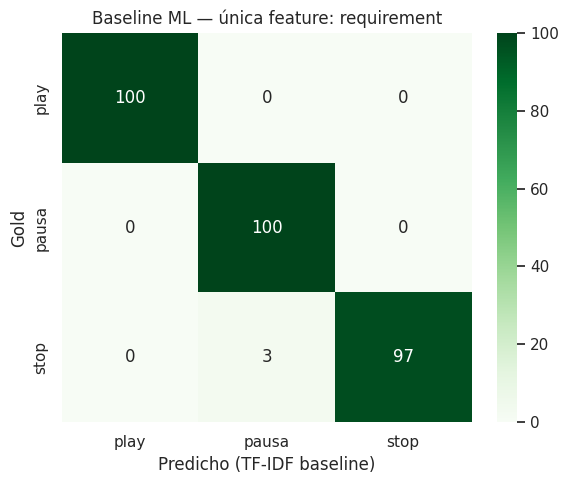

In [4]:
# Baseline ML (mismo feature set que week5): solo requirement
X = df["requirement"].astype(str).to_numpy()
y = df["gold_mode"].astype(str).to_numpy()
groups = df["template_index"].fillna(-1).astype(int).to_numpy()

pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1)),
        (
            "clf",
            LogisticRegression(solver="lbfgs", max_iter=2000, random_state=42),
        ),
    ]
)

gkf = GroupKFold(n_splits=5)
f1s, accs = [], []
y_true_all, y_pred_all = [], []

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    pipe.fit(X[train_idx], y[train_idx])
    yhat = pipe.predict(X[test_idx])
    f1s.append(f1_score(y[test_idx], yhat, labels=LABELS, average="macro", zero_division=0))
    accs.append(accuracy_score(y[test_idx], yhat))
    y_true_all.extend(y[test_idx])
    y_pred_all.extend(yhat)

print(f"GroupKFold (template_index): F1-macro = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"Accuracy media = {np.mean(accs):.3f}")
print(f"Cohen κ (OOF) = {cohen_kappa_score(y_true_all, y_pred_all, labels=LABELS):.3f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicho (TF-IDF baseline)")
ax.set_ylabel("Gold")
ax.set_title("Baseline ML — única feature: requirement")
plt.tight_layout()
plt.show()

Casos pausa clasificados como play (léxico): 6 / 100 pausa


,id,lex_stop,lex_pausa,lex_play,lex_margin
105,CRT-PAUSE-006,0.0,2.0,2.5,0.5
123,CRT-PAUSE-024,0.0,0.0,2.5,2.5
132,CRT-PAUSE-033,0.0,2.0,2.5,0.5
150,CRT-PAUSE-051,0.0,2.0,2.5,0.5
178,CRT-PAUSE-079,0.0,2.0,2.5,0.5
196,CRT-PAUSE-097,0.0,2.0,2.5,0.5


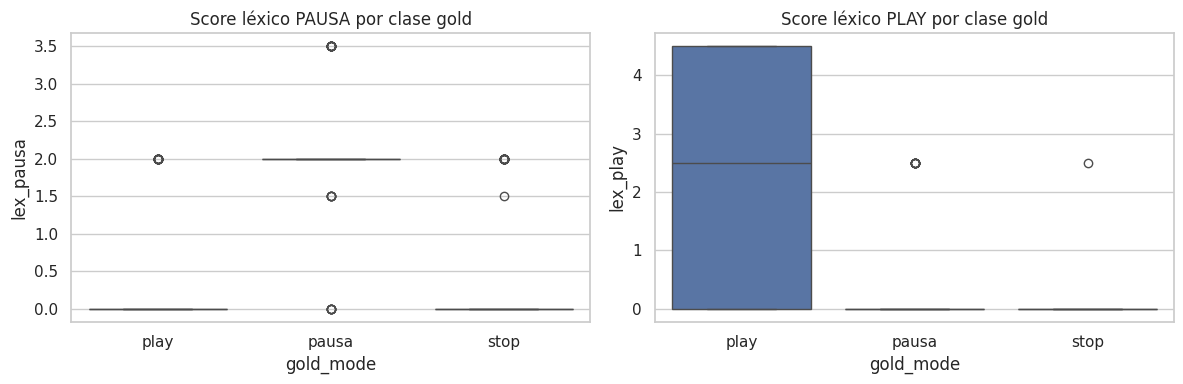

In [5]:
# Diagnóstico: confusión pausa → play (mismo patrón que EarlyGate ~79% acc)
df_diag = df_lex.merge(df[["id", "requirement"]], on="id")  # gold_mode ya está en df_lex
conf_pausa_play = df_diag[(df_diag["gold_mode"] == "pausa") & (df_diag["lex_pred"] == "play")]
print(f"Casos pausa clasificados como play (léxico): {len(conf_pausa_play)} / 100 pausa")
display(conf_pausa_play[["id", "lex_stop", "lex_pausa", "lex_play", "lex_margin"]].head(8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_lex, x="gold_mode", y="lex_pausa", order=LABELS, ax=axes[0])
axes[0].set_title("Score léxico PAUSA por clase gold")
sns.boxplot(data=df_lex, x="gold_mode", y="lex_play", order=LABELS, ax=axes[1])
axes[1].set_title("Score léxico PLAY por clase gold")
plt.tight_layout()
plt.show()

## 5. Tabla resumen — variables correctas del módulo

### Entrada (clasificación textual)

```
requirement: str   # obligatorio
context: dict      # opcional, futuro (metadatos de proyecto estructurados)
```

### Salida (EarlyGate / política)

```
gold_mode: Literal["play", "pausa", "stop"]
confidence: float
doubt: bool
source: str
lexical_scores: {stop, pausa, play}
early_gate_version: str
```

### Evaluación vs gold

```
id, gold_mode, predicted_mode, match, source, confidence, doubt
```

### Métricas (sin vector de probabilidades por clase en EarlyGate)

- **F1-macro**, **Cohen κ**, matriz de confusión
- Por `source` y por clase (recall de **pausa** es el cuello de botella)

### Referencia EarlyGate con API

Para corrida completa con LLM, usar `eval_early_gate_vs_gold.ipynb` (`DEEPSEEK_API_KEY` en `.env`). Resultado conocido (300 casos): accuracy **0.79**, κ **0.69**, 63× `pausa`→`play`.

In [6]:
# Exportar contrato de variables (JSON) para documentación / tesis
contrato = {
    "modulo": "criticidad_operativa",
    "etiquetas": LABELS,
    "entrada_obligatoria": ["requirement"],
    "entrada_opcional": ["context"],
    "corpus_obligatorio": ["id", "gold_mode", "requirement"],
    "corpus_metadatos_eval": ["template_index", "difficulty_hint", "schema_version"],
    "corpus_no_usar_como_feature": ["id", "tags", "rationale_gold"],
    "salida_early_gate": [
        "gold_mode",
        "confidence",
        "doubt",
        "source",
        "lexical_scores",
        "llm_hint",
        "early_gate_version",
        "llm_detail",
    ],
    "features_auxiliares_analisis": [
        "n_chars",
        "n_words",
        "lex_stop",
        "lex_pausa",
        "lex_play",
        "lex_margin",
        "lex_entropy",
    ],
    "capa_distinta_sentinel": {
        "entrada": "blueprint",
        "salida": ["RiskScore", "RiskLevel", "criticality"],
    },
    "patrones_lexicos": {
        "stop": len(STOP_PATTERNS),
        "pausa": len(PAUSE_PATTERNS),
        "play": len(PLAY_PATTERNS),
    },
}

out_path = TESIS2_ROOT / "reports" / "contrato_variables_criticidad.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(contrato, ensure_ascii=False, indent=2), encoding="utf-8")
print("Contrato guardado en:", out_path)
display(pd.Series(contrato["entrada_obligatoria"], name="entrada_obligatoria"))

Contrato guardado en: /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/reports/contrato_variables_criticidad.json


0    requirement
Name: entrada_obligatoria, dtype: str

## 6. Próximos pasos sugeridos

1. **Mejorar recall de `pausa`:** ampliar `PAUSE_PATTERNS` y ajustar prompt LLM (staging sin sonar a "local").
2. **Calibrar umbrales** `EARLY_GATE_CONFIDENCE_OK` / `EARLY_GATE_DOUBT_CONF` con curva confianza–acierto.
3. **Registrar `early_gate` en `llm_config.yaml`** para reproducibilidad del cliente LLM.
4. **No mezclar** `gold_mode` con `criticality` del blueprint sin tabla de correspondencia explícita en la tesis.